In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime as d
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv("./SP500.csv")
data

,Date,Close,High,Low,Open,Volume
0,12/30/1927,17.660000,17.660000,17.660000,17.660000,0
1,1/3/1928,17.760000,17.760000,17.760000,17.760000,0
2,1/4/1928,17.719999,17.719999,17.719999,17.719999,0
3,1/5/1928,17.549999,17.549999,17.549999,17.549999,0
4,1/6/1928,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...,...
24527,8/25/2025,6439.319824,6466.890137,6438.060059,6457.669922,4059070000
24528,8/26/2025,6465.939941,6468.370117,6429.209961,6435.490234,4867680000
24529,8/27/2025,6481.399902,6487.060059,6457.839844,6462.259766,4143680000
24530,8/28/2025,6501.859863,6508.229980,6466.959961,6483.839844,4283760000


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24532 entries, 0 to 24531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    24532 non-null  object 
 1   Close   24532 non-null  float64
 2   High    24532 non-null  float64
 3   Low     24532 non-null  float64
 4   Open    24532 non-null  float64
 5   Volume  24532 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.1+ MB


## Esercizio



Osservare che abbiamo una colonna data, convertiamola in qualcosa di gestibile come un numerico, il numero di giorni a partire dal primo giorno.
Quella colonna data è una stringa, va convertita in un formato date, in python c'è, una volta formattato facciamo la differenza dall'ultimo giorno
al primo e lo salvo in una variabile

In [4]:
#Ho tutte le date della colonna

In [5]:
first_date = d.strptime("12/30/1927", "%m/%d/%Y")
first_date
colonna_data = data["Date"]

In [6]:
lista_datetime_numerici = []
for elemento in colonna_data:
    data_datetime = d.strptime(elemento, "%m/%d/%Y")
    lista_datetime_numerici = lista_datetime_numerici + [(data_datetime - first_date).days]

In [7]:
data["age_in_days"] = lista_datetime_numerici

In [8]:
data.head()

,Date,Close,High,Low,Open,Volume,age_in_days
0,12/30/1927,17.660000,17.660000,17.660000,17.660000,0,0
1,1/3/1928,17.760000,17.760000,17.760000,17.760000,0,4
2,1/4/1928,17.719999,17.719999,17.719999,17.719999,0,5
3,1/5/1928,17.549999,17.549999,17.549999,17.549999,0,6
4,1/6/1928,17.660000,17.660000,17.660000,17.660000,0,7


In [9]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'age_in_days'], dtype='object')

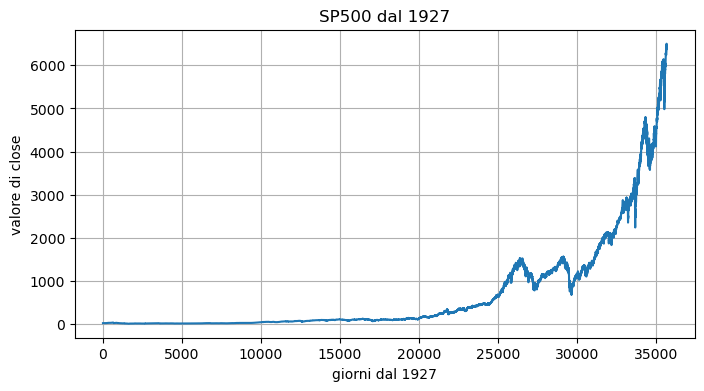

In [10]:
fig, ax = plt.subplots(figsize = (8,4))
ax.plot(data["age_in_days"], data["Close"])
ax.grid()
ax.set_title("SP500 dal 1927")
ax.set_xlabel("giorni dal 1927")
ax.set_ylabel("valore di close")
#ax.scatter(data["age_in_days"], data["Close"])
plt.show()

In [17]:
feature = ['age_in_days'] #Uso solo questo parametro 
output = ["Close"]
selected_data = data[feature+output]

In [12]:
X = selected_data[feature].to_numpy()
y = selected_data[output].to_numpy()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [14]:
regressor = LinearRegression()

In [15]:
regressor.fit(X_train, y_train) #addestra le regressione lineare

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
regressor.score(X_test, y_test)

0.5518132164475947

In [21]:
#Logaritmo di close
data['log'] = np.log(data['Close'])

In [22]:
feature = ['age_in_days'] #Uso solo questo parametro 
output = ["log"]
selected_data = data[feature+output]

In [23]:
X = selected_data[feature].to_numpy()
y = selected_data[output].to_numpy()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [32]:
regressor = LinearRegression()

In [33]:
regressor.fit(X_train, y_train) #addestra le regressione lineare

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
regressor.score(X_test, y_test)

0.9631188985386779

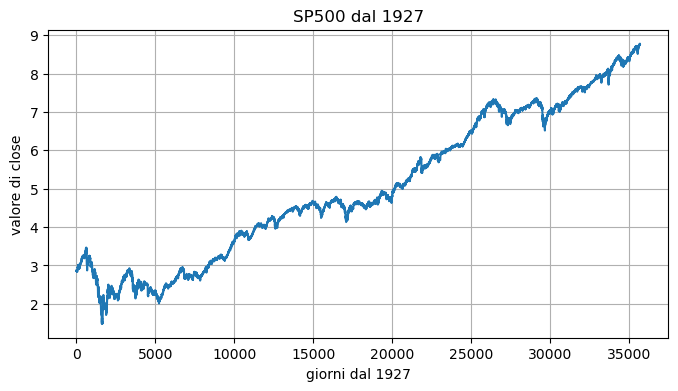

In [35]:
fig, ax = plt.subplots(figsize = (8,4))
ax.plot(data["age_in_days"], data["log"])
ax.grid()
ax.set_title("SP500 dal 1927")
ax.set_xlabel("giorni dal 1927")
ax.set_ylabel("valore di close")
#ax.scatter(data["age_in_days"], data["Close"])
plt.show()